<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>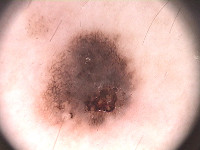</td><td>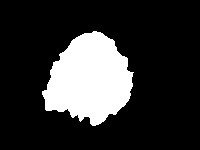</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [ ]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=8f3f0604-019a-4088-87e8-7ed8fa57e5cb
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 152MB/s]


In [ ]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [ ]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [ ]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [ ]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

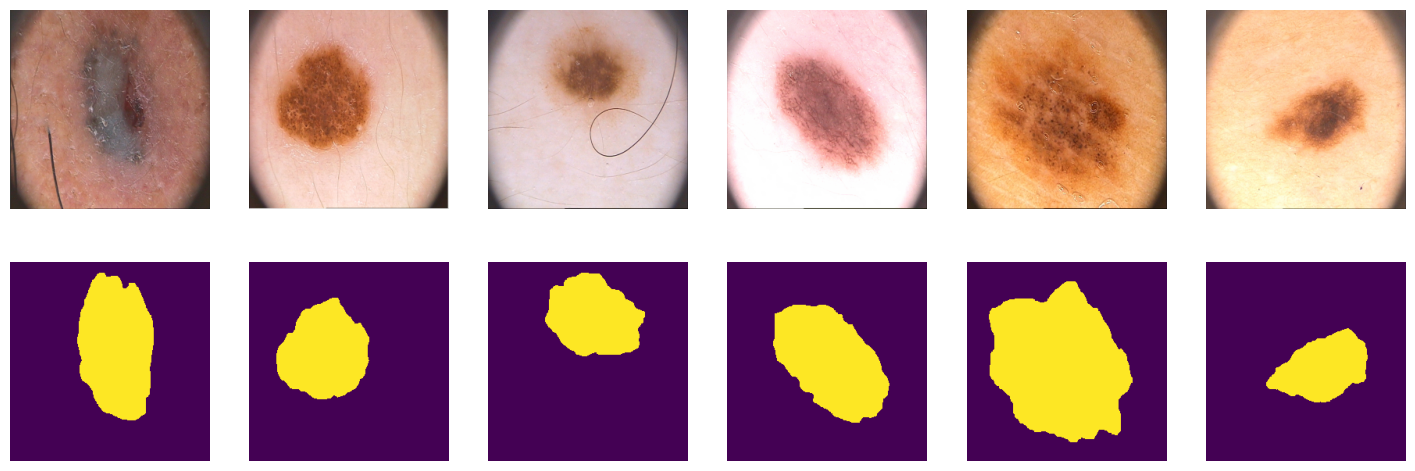

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [ ]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [ ]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [ ]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [ ]:
# !pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.8 MB/s eta 0:00:00


In [ ]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [ ]:
def bce_loss(y_pred_logits, y_real):

    loss = y_pred_logits - y_real * y_pred_logits + torch.log(1 + torch.exp(-y_pred_logits))

    return loss.sum()

def bce_true(y_pred_logits, y_real):

    y_pred_prob = torch.sigmoid(y_pred_logits)

    loss = - (y_real * torch.log(y_pred_prob) + (1 - y_real) * torch.log(1 - y_pred_prob))

    return loss.sum()

Проверим корректность работы на простом примере

In [ ]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.402291297912598
BCE loss честно посчитанный                = 4.402291297912598
BCE loss from torch bce_torch              = 4.402291297912598
BCE loss from torch with logits bce_torch  = 4.402291774749756


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [ ]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 16.687864303588867
BCE loss честно посчитанный               = 16.687864303588867
BCE loss from torch bce_torch             = 16.687864303588867
BCE loss from torch with logits bce_torch = 16.687864303588867


In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [ ]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 7.41MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 5.13MB/s]
Download completed


In [ ]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

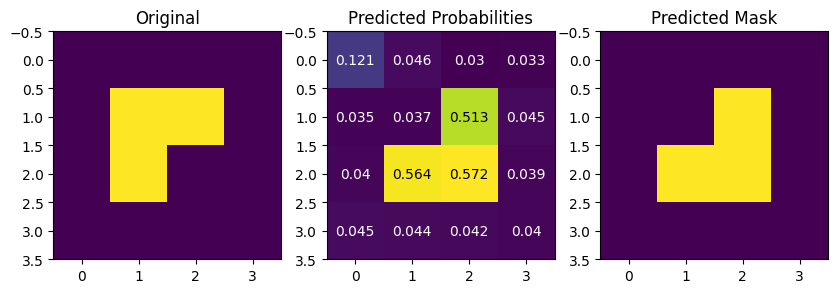

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [ ]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

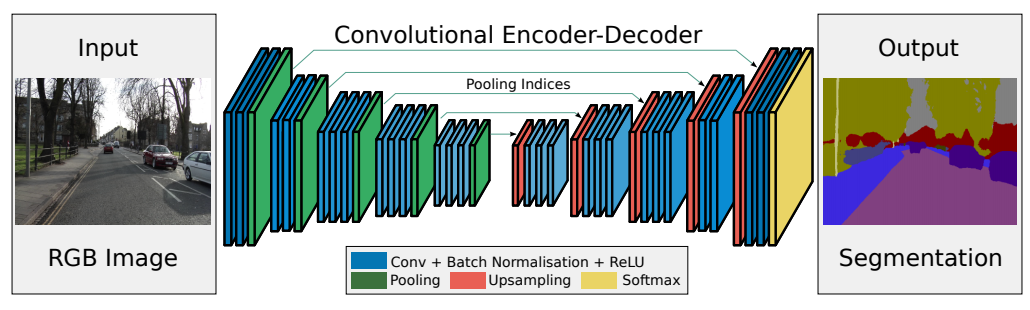

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [ ]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 70.6MB/s]


In [ ]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [ ]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, last_layer=False):
        super().__init__()
        self.layers = nn.ModuleList()

        # Первый Conv всегда с BN+ReLU
        self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth - 1):
            self.layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
            # Если это последний блок декодера и последний Conv в нём -> не добавляем активацию
            if not (last_layer and i == depth - 2):
                self.layers.append(nn.BatchNorm2d(out_channels))
                self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        x = F.max_unpool2d(x, indices, kernel_size=2, stride=2)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [ ]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=32):
        super().__init__()
        # 3 уровня энкодера
        self.enc1 = EncoderBlock(in_channels, num_features, depth=2)    # 3->32
        self.enc2 = EncoderBlock(num_features, num_features*2, depth=2) # 32->64
        self.enc3 = EncoderBlock(num_features*2, num_features*4, depth=3) # 64->128
        # Декодер симметрично
        self.dec3 = DecoderBlock(num_features*4, num_features*2, depth=3) # 128->64
        self.dec2 = DecoderBlock(num_features*2, num_features, depth=2)   # 64->32
        self.dec1 = DecoderBlock(num_features, out_channels, depth=2, last_layer=True)     # 32->1

    def forward(self, x):
        x, idx1 = self.enc1(x)
        x, idx2 = self.enc2(x)
        x, idx3 = self.enc3(x)
        x = self.dec3(x, idx3)
        x = self.dec2(x, idx2)
        x = self.dec1(x, idx1)
        return x

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [ ]:
from tqdm import tqdm

***Небольшой дисклеймер: у меня возникли проблемы с обучение модели, поэтому я допиливал код обучения через нейронку в части диагностики. Поэтому в коде присутствуют комменты от нейронки.***

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, scheduler=None, metrics=None, save_path='/content/best_segnet.pth'):
    """
    Универсальная функция обучения модели сегментации с сохранением лучшего чекпоинта по IoU.
    """
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'val_iou': []}
    best_val_iou = -1.0  # <-- Инициализация лучшей метрики

    # --- Инициализация метрики IoU ---
    if metrics is None:
        iou_metric = JaccardIndex(task='binary', threshold=0.5, average='binary').to(device)
    else:
        iou_metric = metrics

    if iou_metric is not None:
        if hasattr(iou_metric, 'average') and iou_metric.average == 'none':
            print("Внимание: метрика JaccardIndex имеет average='none'. Принудительно меняем на 'binary'.")
            iou_metric = JaccardIndex(task='binary', threshold=0.5, average='binary').to(device)

    for epoch in range(1, num_epochs + 1):
        # ---------- Training ----------
        model.train()
        train_loss = 0.0
        loop = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} [Train]', leave=False)

        for images, masks in loop:
            images = images.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()

            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            loop.set_postfix(loss=loss.item())

        train_loss /= len(train_loader.dataset)

        # ---------- Validation ----------
        model.eval()
        val_loss = 0.0
        val_iou = 0.0
        debug_printed = False

        with torch.no_grad():
            for i, (images, masks) in enumerate(val_loader):
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

                if epoch == 1 and i == 0 and not debug_printed:
                    probs = torch.sigmoid(outputs)
                    preds_bin = (probs >= 0.5).int()
                    print("\n========== DEBUG ==========")
                    print(f"Probs: min={probs.min().item():.4f}, max={probs.max().item():.4f}, mean={probs.mean().item():.4f}")
                    print(f"Masks: min={masks.min().item():.1f}, max={masks.max().item():.1f}, positive ratio={masks.float().mean().item():.4f}")
                    intersection = (preds_bin & masks.int()).sum().float()
                    union = (preds_bin | masks.int()).sum().float()
                    manual_iou = (intersection / union).item() if union > 0 else 0.0
                    print(f"Manual IoU (batch 0, threshold=0.5): {manual_iou:.4f}")
                    obj_probs = probs[masks == 1]
                    bg_probs = probs[masks == 0]
                    if obj_probs.numel() > 0: print(f"Prob on object: mean={obj_probs.mean().item():.4f}, std={obj_probs.std().item():.4f}")
                    else: print("Prob on object: нет пикселей объекта в батче")
                    if bg_probs.numel() > 0: print(f"Prob on background: mean={bg_probs.mean().item():.4f}, std={bg_probs.std().item():.4f}")
                    preds_low = (probs >= 0.1).int()
                    intersection_low = (preds_low & masks.int()).sum().float()
                    union_low = (preds_low | masks.int()).sum().float()
                    manual_iou_low = (intersection_low / union_low).item() if union_low > 0 else 0.0
                    print(f"Manual IoU with threshold 0.1: {manual_iou_low:.4f}")
                    print("============================\n")
                    debug_printed = True

                if iou_metric is not None:
                    preds = (torch.sigmoid(outputs) >= 0.5).int()
                    iou_metric.update(preds, masks.int())

            val_loss /= len(val_loader.dataset)
            if iou_metric is not None:
                val_iou = iou_metric.compute().item()
                iou_metric.reset()

        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)

        print(f'\nEpoch {epoch:2d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Val IoU: {val_iou:.4f}')

        # 💾 --- СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ ---
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), save_path)
            print(f"Лучший результат по IoU: {val_iou:.4f} -> {save_path}")

        # Планировщик
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                # 💡 Совет: если хочешь, чтобы шедулер реагировал на IoU, поменяй mode='max' и передавай val_iou
                scheduler.step(val_loss)
            else:
                scheduler.step()

    print(f"\n Обучение завершено. ЛУчший Val IoU: {best_val_iou:.4f} (модель сохранена тут: {save_path})")
    return model, history

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

***Дисклеймер №1: при обучении я использовал не самописный, а торчевский лосс BCE, почему то с самописным обучение часто вствало в самом начале. Почему я понять не смог, реализован он вроде бы правильно.***

In [ ]:
num_epoch = 200
model = SegNet(in_channels=3, out_channels=1)
batch_size = 4
criterion = nn.BCEWithLogitsLoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
model, history = train_model(model=model,
                             train_loader=train_dataloader,
                             val_loader=valid_dataloader,
                             criterion=criterion,
                             optimizer=optimizer,
                             num_epochs=num_epoch,
                             device=device,
                             scheduler=scheduler,
                             metrics=iou_score)


========== DEBUG ==========
Probs: min=0.4937, max=0.4977, mean=0.4957
Masks: min=0.0, max=1.0, positive ratio=0.3789
Manual IoU (batch 0, threshold=0.5): 0.0000
Prob on object: mean=0.4957, std=0.0002
Prob on background: mean=0.4957, std=0.0001
Manual IoU with threshold 0.1: 0.3789


Epoch  1/200 | Train Loss: 0.691686 | Val Loss: 0.690497 | Val IoU: 0.0000
Лучший результат по IoU: 0.0000 -> /content/best_segnet.pth



Epoch  2/200 | Train Loss: 0.648957 | Val Loss: 0.689905 | Val IoU: 0.0000



Epoch  3/200 | Train Loss: 0.631137 | Val Loss: 0.689333 | Val IoU: 0.0000



Epoch  4/200 | Train Loss: 0.606763 | Val Loss: 0.688754 | Val IoU: 0.0000



Epoch  5/200 | Train Loss: 0.595277 | Val Loss: 0.688170 | Val IoU: 0.0000


...


Epoch 196/200 | Train Loss: 0.511948 | Val Loss: 0.525576 | Val IoU: 0.7922



Epoch 197/200 | Train Loss: 0.515369 | Val Loss: 0.525573 | Val IoU: 0.7922



Epoch 198/200 | Train Loss: 0.520522 | Val Loss: 0.525966 | Val IoU: 0.7917



Epoch 199/200 | Train Loss: 0.512197 | Val Loss: 0.525868 | Val IoU: 0.7918



Epoch 200/200 | Train Loss: 0.511119 | Val Loss: 0.525799 | Val IoU: 0.7920

 Обучение завершено. ЛУчший Val IoU: 0.7929 (модель сохранена тут: /content/best_segnet.pth)


In [ ]:
!cp /content/best_segnet.pth /content/drive/MyDrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [ ]:
import torch
import torch.nn.functional as F

def test_model(model, test_loader, device, checkpoint_path, criterion, metric):
    """
    Загружает веса, оценивает модель на тестовом наборе и возвращает метрики + примеры.
    """
    # Загрузка сохраненных весов модели или полного чекпоинта
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded full checkpoint (epoch {checkpoint.get('epoch', '?')})")
    else:
        model.load_state_dict(checkpoint)
        print("Loaded plain state_dict")

    model.to(device)
    model.eval()

    # Сбрасываем метрику
    metric.to(device)
    metric.reset()

    test_loss = 0.0
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)


            masks_float = masks.float()

            loss = criterion(outputs, masks_float)
            test_loss += loss.item() * images.size(0)

            # Бинаризация предсказаний для метрики
            preds = (torch.sigmoid(outputs) >= 0.5).int()
            metric.update(preds, masks.int())

            # Сохраняем первые 4 батча для визуализации
            if len(all_preds) < 4:
                all_preds.append(preds.cpu())
                all_masks.append(masks.cpu())

    test_loss /= len(test_loader.dataset)

    # Если лосс отрицательный - значит где то косяк
    if test_loss < 0:
        print("\n ВНИМАНИЕ: Test Loss отрицательный!")
        print("   BCE и Dice лоссы ≥ 0 по определению.")
        print("   Возможные причины:")
        print("   1. В criterion используется `dice - 1` вместо `1 - dice`")
        print("   2. Передается criterion из обучения с модификациями (например, `-criterion`)")
        print("   3. Ошибка dtype: маски int/long вместо float для BCE")

    metric_value = metric.compute().item()

    print(f"Test Loss: {test_loss:.6f}")
    print(f"Test IoU:  {metric_value:.4f}")

    return {
        'loss': test_loss,
        'metric': metric_value,
        'predictions': all_preds,
        'targets': all_masks,
    }

In [ ]:
results = test_model(
    model=model,
    test_loader=test_dataloader,
    device=device,
    checkpoint_path='/content/best_segnet.pth',
    criterion=criterion,
    metric=iou_score
)

Loaded plain state_dict
Test Loss: 0.572993
Test Metric: 0.7331


# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [ ]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5, eps: float = 1e-8):
    """
    Dice коэффициент, вычисленный глобально по всему батчу (micro average).
    """
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    preds_flat = preds.reshape(-1)
    labels_flat = labels.reshape(-1)
    tp = (preds_flat * labels_flat).sum()
    fp = (preds_flat * (1 - labels_flat)).sum()
    fn = ((1 - preds_flat) * labels_flat).sum()
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    return dice

Проверим на корректность функцию dice_score:

In [ ]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.3158, device='cuda:0')

In [ ]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

***Дисклеймер №2: почему то у меня не проходил ассерт, хотя вроде бы все правильно. Возможно это из-за каких то особенностей реализации торчевской метрики, я хз.***

In [ ]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

AssertionError: 

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [ ]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor, eps: float = 1e-8):
    """
    Дифференцируемый Dice Loss.

    Args:
        logits: тензор логитов (B, 1, H, W) или (B, H, W)
        labels: тензор истинных масок (B, 1, H, W) или (B, H, W) со значениями 0/1
        eps: малая константа для численной стабильности

    Returns:
        скалярный тензор потери
    """
    # Приводим к вероятностям через сигмоид (без порога)
    probs = torch.sigmoid(logits)

    # Сглаживаем все измерения кроме batch (оставляем размерность [B, -1])
    probs_flat = probs.view(probs.size(0), -1)
    labels_flat = labels.view(labels.size(0), -1)

    # Мягкие TP, FP, FN
    tp = (probs_flat * labels_flat).sum(dim=1)
    fp = (probs_flat * (1 - labels_flat)).sum(dim=1)
    fn = ((1 - probs_flat) * labels_flat).sum(dim=1)

    # Dice коэффициент для каждого элемента батча
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    # Dice Loss = 1 - Dice, усредненный по батчу
    loss = (1 - dice).mean()
    return loss

Проверка на корректность:

In [ ]:
# проверьте, что у вас установлена библиотека
# !pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.3 MB/s eta 0:00:00


In [ ]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [ ]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [ ]:
def focal_loss(y_real: torch.Tensor, y_pred: torch.Tensor, gamma: float = 2.0, reduction: str = 'mean'):
    """
    Focal Loss для бинарной сегментации.
    y_real: истинные маски (0/1)
    y_pred: логиты сети
    """
    ce = torch.nn.functional.binary_cross_entropy_with_logits(y_pred, y_real, reduction='none')
    prob = torch.sigmoid(y_pred)
    p_t = prob * y_real + (1 - prob) * (1 - y_real)
    loss = ce * ((1 - p_t) ** gamma)
    if reduction == 'sum':
        return loss.sum()
    elif reduction == 'mean':
        return loss.mean()
    return loss

Проверка корректности функции:

In [ ]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [ ]:
torch_value = sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')
my_value = focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0, reduction='sum')
assert torch.allclose(torch_value, my_value, atol=1e-6)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [ ]:
num_epoch = 200
model = SegNet(in_channels=3, out_channels=1)
batch_size = 4
criterion = dice_loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
model, history = train_model(model=model,
                             train_loader=train_dataloader,
                             val_loader=valid_dataloader,
                             criterion=criterion,
                             optimizer=optimizer,
                             num_epochs=num_epoch,
                             device=device,
                             scheduler=scheduler,
                             metrics=iou_score)


========== DEBUG ==========
Probs: min=0.5146, max=0.5237, mean=0.5203
Masks: min=0.0, max=1.0, positive ratio=0.3331
Manual IoU (batch 0, threshold=0.5): 0.3331
Prob on object: mean=0.5202, std=0.0011
Prob on background: mean=0.5203, std=0.0009
Manual IoU with threshold 0.1: 0.3331


Epoch  1/200 | Train Loss: 0.665592 | Val Loss: 0.620029 | Val IoU: 0.3585
Лучший результат по IoU: 0.3585 -> /content/best_segnet.pth



Epoch  2/200 | Train Loss: 0.661018 | Val Loss: 0.619635 | Val IoU: 0.3585



Epoch  3/200 | Train Loss: 0.658810 | Val Loss: 0.619325 | Val IoU: 0.3585



Epoch  4/200 | Train Loss: 0.656559 | Val Loss: 0.619010 | Val IoU: 0.3585
Лучший результат по IoU: 0.3585 -> /content/best_segnet.pth



Epoch  5/200 | Train Loss: 0.654512 | Val Loss: 0.618419 | Val IoU: 0.3631
Лучший результат по IoU: 0.3631 -> /content/best_segnet.pth


...


Epoch 196/200 | Train Loss: 0.602713 | Val Loss: 0.563639 | Val IoU: 0.6098



Epoch 197/200 | Train Loss: 0.602949 | Val Loss: 0.563375 | Val IoU: 0.6110



Epoch 198/200 | Train Loss: 0.602831 | Val Loss: 0.563442 | Val IoU: 0.6102



Epoch 199/200 | Train Loss: 0.602685 | Val Loss: 0.563395 | Val IoU: 0.6103



Epoch 200/200 | Train Loss: 0.602482 | Val Loss: 0.563471 | Val IoU: 0.6105

 Обучение завершено. ЛУчший Val IoU: 0.6303 (модель сохранена тут: /content/best_segnet.pth)


In [ ]:
num_epoch = 200
model = SegNet(in_channels=3, out_channels=1)
batch_size = 8
criterion = focal_loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

In [ ]:
model, history = train_model(model=model,
                             train_loader=train_dataloader,
                             val_loader=valid_dataloader,
                             criterion=criterion,
                             optimizer=optimizer,
                             num_epochs=num_epoch,
                             device=device,
                             scheduler=scheduler,
                             metrics=iou_score)


========== DEBUG ==========
Probs: min=0.4529, max=0.4670, mean=0.4585
Masks: min=0.0, max=1.0, positive ratio=0.3331
Manual IoU (batch 0, threshold=0.5): 0.0000
Prob on object: mean=0.4585, std=0.0011
Prob on background: mean=0.4585, std=0.0012
Manual IoU with threshold 0.1: 0.3331


Epoch  1/200 | Train Loss: 0.322669 | Val Loss: 0.457511 | Val IoU: 0.2208
Лучший результат по IoU: 0.2208 -> /content/best_segnet.pth



Epoch  2/200 | Train Loss: 0.242330 | Val Loss: 0.455909 | Val IoU: 0.0000



Epoch  3/200 | Train Loss: 0.212609 | Val Loss: 0.453697 | Val IoU: 0.0000



Epoch  4/200 | Train Loss: 0.193011 | Val Loss: 0.451598 | Val IoU: 0.0000



Epoch  5/200 | Train Loss: 0.181778 | Val Loss: 0.448845 | Val IoU: 0.0036


...


Epoch 196/200 | Train Loss: -75.913470 | Val Loss: -45.748171 | Val IoU: 0.1998



Epoch 197/200 | Train Loss: -64.007016 | Val Loss: -345.802719 | Val IoU: 0.1202



Epoch 198/200 | Train Loss: -163.172600 | Val Loss: -45.910679 | Val IoU: 0.2525



Epoch 199/200 | Train Loss: -244.331703 | Val Loss: -44.237453 | Val IoU: 0.2063



Epoch 200/200 | Train Loss: -282.266385 | Val Loss: -45.942487 | Val IoU: 0.0201

 Обучение завершено. ЛУчший Val IoU: 0.7618 (модель сохранена тут: /content/best_segnet.pth)


In [ ]:
results = test_model(
    model=model,
    test_loader=test_dataloader,
    device=device,
    checkpoint_path='/content/best_segnet_dice.pth',
    criterion=criterion,
    metric=iou_score
)

Loaded plain state_dict
Test Loss: 0.312733
Test Metric: 0.6742


In [ ]:
results = test_model(
    model=model,
    test_loader=test_dataloader,
    device=device,
    checkpoint_path='/content/best_segnet_foccal.pth',
    criterion=criterion,
    metric=iou_score
)

Loaded plain state_dict
Test Loss: 0.160451
Test Metric: 0.7553


Ответы на вопросики:

Вообщем наилучшие результаты и сходимость(на 13 эпохе) показала Foccal_Loss, почему? Ну тут ряд особенностей:

1. Из-за маленького датасета мне пришлось сильно уменьшить размер батча(до 4) и использовать не 5 слоев(как я изначально планировал), а всего 3 слоя в моделе;
2. В архитектуре модели использовался max_unpool2d - из-за которого сильно размывалось изображение на границах, что затрудняет обучение;
3. В обучающем датасете всего 100 изображений - соответсвенно модель могла их быстро запомнить и начать переобучаться, из-за чего все шло по 3.14*зде;

Поэтому в моем случае Foccal_Loss по сути решал все эти проблемы, а именно:

1. Foccal_Loss считает лосс по-пиксельно, поэтому стабилен даже на малых батчах;
2. Из-за размазвания изображения на границе модель получает много пикселей с "неуверенным" предсказанием, Foccal_Loss может отлично с ними работать;
3. Foccal_Loss снижает вес уверенных предсказаний, замедляет запоминание фона и помогает моделе изучать общие признаки, на малой тестовой выборки это дает хороший результат.

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

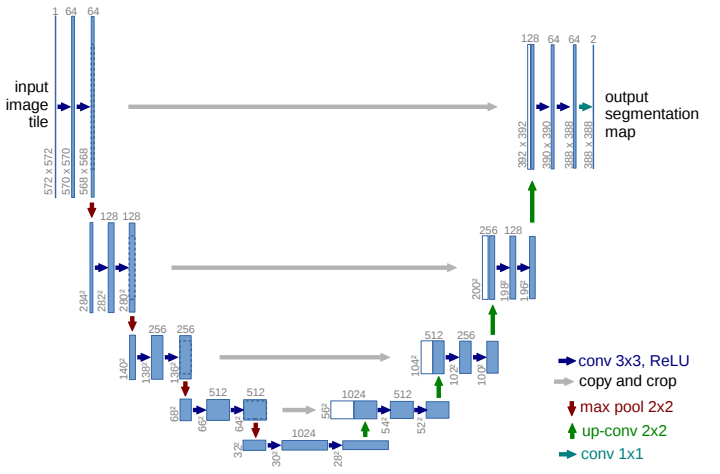

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth=2, kernel_size=3, padding=1):
        super().__init__()
        self.layers = nn.ModuleList()

        self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for _ in range(depth - 1):
            self.layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        skip = x
        x_pooled = self.pool(x)
        return x_pooled, skip


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, depth=2, kernel_size=3, padding=1):
        super().__init__()

        # Upsampling через транспонированную свёртку
        self.upsample = nn.ConvTranspose2d(
            in_channels, out_channels, kernel_size=2, stride=2
        )

        # Конволюционные слои после конкатенации
        concat_channels = out_channels + skip_channels

        self.layers = nn.ModuleList()
        self.layers.append(nn.Conv2d(concat_channels, out_channels, kernel_size, padding=padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for _ in range(depth - 1):
            self.layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, skip):

        x = self.upsample(x)

        # Skip-connection с выравниванием размеров
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        skip = F.pad(skip, [diff_x // 2, diff_x - diff_x // 2,
                            diff_y // 2, diff_y - diff_y // 2])

        # Конкатенация
        x = torch.cat([x, skip], dim=1)

        # Конволюционные слои
        for layer in self.layers:
            x = layer(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels=3, n_class=1, base_features=64):
        super().__init__()

        # Encoder
        self.enc1 = EncoderBlock(in_channels, base_features, depth=2)
        self.enc2 = EncoderBlock(base_features, base_features*2, depth=2)
        self.enc3 = EncoderBlock(base_features*2, base_features*4, depth=2)
        self.enc4 = EncoderBlock(base_features*4, base_features*8, depth=2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_features*8, base_features*16, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_features*16),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_features*16, base_features*16, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_features*16),
            nn.ReLU(inplace=True)
        )

        # Decoder
        self.dec4 = DecoderBlock(base_features*16, base_features*8, base_features*8, depth=2)
        self.dec3 = DecoderBlock(base_features*8, base_features*4, base_features*4, depth=2)
        self.dec2 = DecoderBlock(base_features*4, base_features*2, base_features*2, depth=2)
        self.dec1 = DecoderBlock(base_features*2, base_features, base_features, depth=2)

        # Output
        self.final_conv = nn.Conv2d(base_features, n_class, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1, skip1 = self.enc1(x)
        x2, skip2 = self.enc2(x1)
        x3, skip3 = self.enc3(x2)
        x4, skip4 = self.enc4(x3)

        # Bottleneck
        x = self.bottleneck(x4)

        # Decoder с skip-connections
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        # Output
        return self.final_conv(x)

In [ ]:
unet_model_bce = UNet(in_channels=3, n_class=1, base_features=32).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(unet_model_bce.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
model, history = train_model(
    model=unet_model_bce,
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=200,
    device=device,
    scheduler=scheduler,
    save_path='/content/best_unet_bce.pth'
)


========== DEBUG ==========
Probs: min=0.5260, max=0.5391, mean=0.5315
Masks: min=0.0, max=1.0, positive ratio=0.3331
Manual IoU (batch 0, threshold=0.5): 0.3331
Prob on object: mean=0.5326, std=0.0013
Prob on background: mean=0.5309, std=0.0016
Manual IoU with threshold 0.1: 0.3331


Epoch  1/200 | Train Loss: 0.661422 | Val Loss: 0.711550 | Val IoU: 0.3585
Лучший результат по IoU: 0.3585 -> /content/best_unet_bce.pth



Epoch  2/200 | Train Loss: 0.463230 | Val Loss: 0.701445 | Val IoU: 0.3583



Epoch  3/200 | Train Loss: 0.448092 | Val Loss: 0.663276 | Val IoU: 0.0007



Epoch  4/200 | Train Loss: 0.395636 | Val Loss: 0.629326 | Val IoU: 0.0000



Epoch  5/200 | Train Loss: 0.378110 | Val Loss: 0.790960 | Val IoU: 0.0000


...


Epoch 196/200 | Train Loss: 0.112475 | Val Loss: 0.357921 | Val IoU: 0.7373



Epoch 197/200 | Train Loss: 0.107855 | Val Loss: 0.368437 | Val IoU: 0.7256



Epoch 198/200 | Train Loss: 0.091646 | Val Loss: 0.331284 | Val IoU: 0.7519



Epoch 199/200 | Train Loss: 0.085532 | Val Loss: 0.218600 | Val IoU: 0.8102



Epoch 200/200 | Train Loss: 0.107730 | Val Loss: 0.240368 | Val IoU: 0.8045

 Обучение завершено. ЛУчший Val IoU: 0.8638 (модель сохранена тут: /content/best_unet_bce.pth)


In [ ]:
unet_model_dice = UNet(in_channels=3, n_class=1, base_features=32).to(device)
criterion = dice_loss
optimizer = torch.optim.Adam(unet_model_dice.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
model, history = train_model(
    model=unet_model_dice,
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=200,
    device=device,
    scheduler=scheduler,
    save_path='/content/best_unet_dice.pth'
)


========== DEBUG ==========
Probs: min=0.4913, max=0.5174, mean=0.4990
Masks: min=0.0, max=1.0, positive ratio=0.3331
Manual IoU (batch 0, threshold=0.5): 0.3712
Prob on object: mean=0.5011, std=0.0035
Prob on background: mean=0.4979, std=0.0028
Manual IoU with threshold 0.1: 0.3331


Epoch  1/200 | Train Loss: 0.567495 | Val Loss: 0.625236 | Val IoU: 0.4112
Лучший результат по IoU: 0.4112 -> /content/best_unet_dice.pth



Epoch  2/200 | Train Loss: 0.466355 | Val Loss: 0.659082 | Val IoU: 0.0000



Epoch  3/200 | Train Loss: 0.429564 | Val Loss: 0.695634 | Val IoU: 0.0000



Epoch  4/200 | Train Loss: 0.412627 | Val Loss: 0.694309 | Val IoU: 0.0217



Epoch  5/200 | Train Loss: 0.398307 | Val Loss: 0.650092 | Val IoU: 0.1464


...


Epoch 196/200 | Train Loss: 0.058686 | Val Loss: 0.119394 | Val IoU: 0.7817



Epoch 197/200 | Train Loss: 0.060345 | Val Loss: 0.105192 | Val IoU: 0.8060



Epoch 198/200 | Train Loss: 0.062164 | Val Loss: 0.122788 | Val IoU: 0.7904



Epoch 199/200 | Train Loss: 0.070923 | Val Loss: 0.091032 | Val IoU: 0.8522



Epoch 200/200 | Train Loss: 0.059485 | Val Loss: 0.123617 | Val IoU: 0.8127

 Обучение завершено. ЛУчший Val IoU: 0.8771 (модель сохранена тут: /content/best_unet_dice.pth)


In [ ]:
unet_model_focal = UNet(in_channels=3, n_class=1, base_features=32).to(device)
criterion = focal_loss
optimizer = torch.optim.Adam(unet_model_focal.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
model, history = train_model(
    model=unet_model_focal,
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=200,
    device=device,
    scheduler=scheduler,
    save_path='/content/best_unet_focal.pth'
)


========== DEBUG ==========
Probs: min=0.4618, max=0.4737, mean=0.4668
Masks: min=0.0, max=1.0, positive ratio=0.3331
Manual IoU (batch 0, threshold=0.5): 0.0000
Prob on object: mean=0.4686, std=0.0017
Prob on background: mean=0.4660, std=0.0021
Manual IoU with threshold 0.1: 0.3331


Epoch  1/200 | Train Loss: 0.242607 | Val Loss: 0.432389 | Val IoU: 0.0000
Лучший результат по IoU: 0.0000 -> /content/best_unet_focal.pth



Epoch  2/200 | Train Loss: 0.156186 | Val Loss: 0.479438 | Val IoU: 0.0000



Epoch  3/200 | Train Loss: 0.142981 | Val Loss: 0.511062 | Val IoU: 0.0986
Лучший результат по IoU: 0.0986 -> /content/best_unet_focal.pth



Epoch  4/200 | Train Loss: 0.139275 | Val Loss: 0.625272 | Val IoU: 0.3339
Лучший результат по IoU: 0.3339 -> /content/best_unet_focal.pth



Epoch  5/200 | Train Loss: 0.135794 | Val Loss: 0.589541 | Val IoU: 0.4091
Лучший результат по IoU: 0.4091 -> /content/best_unet_focal.pth


...


Epoch 196/200 | Train Loss: -3741.849262 | Val Loss: -4732955.750000 | Val IoU: 0.3609



Epoch 197/200 | Train Loss: -339.444435 | Val Loss: -4974167.812500 | Val IoU: 0.3444



Epoch 198/200 | Train Loss: -898.351685 | Val Loss: -282538.613281 | Val IoU: 0.3066



Epoch 199/200 | Train Loss: -1695.353546 | Val Loss: -12102.162109 | Val IoU: 0.3426



Epoch 200/200 | Train Loss: -3028.416748 | Val Loss: -9468.293457 | Val IoU: 0.3128

 Обучение завершено. ЛУчший Val IoU: 0.5986 (модель сохранена тут: /content/best_unet_focal.pth)


## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



In [ ]:
results_bce = test_model(
    model=unet_model_bce,
    test_loader=test_dataloader,
    device=device,
    checkpoint_path='/content/best_unet_bce.pth',
    criterion=nn.BCEWithLogitsLoss(),
    metric=iou_score
)

Loaded plain state_dict
Test Loss: 0.146104
Test IoU:  0.8565


In [ ]:
results_dice = test_model(
    model=unet_model_dice,
    test_loader=test_dataloader,
    device=device,
    checkpoint_path='/content/best_unet_dice.pth',
    criterion=dice_loss,
    metric=iou_score
)

Loaded plain state_dict
Test Loss: 0.083634
Test IoU:  0.8664


In [ ]:
results_bce = test_model(
    model=unet_model_focal,
    test_loader=test_dataloader,
    device=device,
    checkpoint_path='/content/best_unet_focal.pth',
    criterion=focal_loss,
    metric=iou_score
)

Loaded plain state_dict
Test Loss: 0.241283
Test IoU:  0.6751


БАРАБАННАЯ ДРОБЬ!!!!

В этом раунде по всем показателям выиграла модель с функцией потерь - Dice Loss, а хуже всего показал победитель предыдущего раунда Focal Loss.
Результат интересный, конечно.

Почемуу так получилось:

1. В отличии от SegNet в U-net есть скип-коннекшн, поэтмоу focal тут может навредить. В SigNet это наоборот помогало бороться с потерей информации;
2. В dice лучшее использует информаию для обобщения, если нет пространственной потери;
3. U-Net дает четкие карты признаков и стабильные градиенты даже при небольшом размере батча, благодаря чему dice хорошо отрабатывает и помогает быстро откалибровать вероятности;